In [3]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 경로 설정
import os 
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12,6)

# 시드 설정
np.random.seed(42)

print('-' * 60)
print('라이브러리 로드 완료')
print('한글 폰트 설정 완료!')
print('-'* 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [4]:
os.chdir(os.path.abspath('..'))
print(os.getcwd())

df_cleaned = pd.read_csv('data/df_cleaned.csv')
display(df_cleaned.head())

c:\Users\kims\Documents\airbnb_price_prediction


,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_verifications_email,host_verifications_phone,host_verifications_work_email,log_price,log_estimated_revenue_l365d
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",I’m an urban planner working for an internatio...,NaN,NaN,NaN,False,Prospect Heights,1.0,3.0,True,True,Neighborhood highlights,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200.0,90,365,90.0,90.0,365.0,365.0,90.0,365.0,True,27,57,87,362,9,0,0,301,0,0,0.0,2010-12-11,2013-05-10,4.88,5.00,4.80,5.00,5.00,5.00,5.00,NaN,False,1,0,1,0,0.05,1,1,1,5.303305,0.000000
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",NaN,NaN,NaN,1.00,False,East Harlem,1.0,1.0,True,True,Neighborhood highlights,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1 private bath,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82.0,30,999,30.0,30.0,999.0,999.0,30.0,999.0,True,0,0,0,204,102,0,0,143,0,0,0.0,2010-10-04,2023-12-09,4.77,4.82,4.76,4.88,4.90,4.38,4.71,NaN,False,1,0,1,0,0.58,1,1,0,4.418841,0.000000
2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",I am a lawyer and work as an executive at an a...,within a few hours,1.0,0.40,False,Boerum Hill,1.0,3.0,True,True,Neighborhood highlights,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765.0,3,60,3.0,3.0,60.0,60.0,3.0,60.0,True,30,49,66,326,43,0,0,267,0,0,0.0,2012-07-09,2023-08-30,4.70,4.83,4.52,4.88,4.88,4.86,4.62,OSE-STRREG-0001784,False,1,0,1,0,0.28,1,1,1,6.641182,0.000000
3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,West Harlem is now packed with great restauran...,166532,Matthew,2010-07-14,"New York, NY",I have been a New Yorker for a long time\n and...,within an hour,1.0,0.97,True,Harlem,1.0,1.0,True,True,Neighborhood highlights,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",139.0,2,45,2.0,2.0,1125.0,1125.0,2.0,1125.0,True,7,18,25,25,241,42,3,25,43,255,35445.0,2010-08-28,2025-02-21,4.85,4.87,4.50,4.96,4.96,4.79,4.82,OSE-STRREG-0000476,False,1,1,0,0,1.36,1,1,0,4.941642,10.475

In [5]:
df_cleaned_copy = df_cleaned.copy()

# 주요 변수와 가격(price)과의 상관관계 분석-> 7개+리뷰, 평점
    주요 변수: 
        리뷰관련 + 평점, 
        estimated_occupancy_l365d (지난 365일(1년) 동안 숙소가 얼마나 이 숙소가 얼마나 찼었는지 추정한 점유율)
        property_type (숙소 타입) 
        room_type (룸 타입)
        host_is_superhost (슈퍼 호스트 여부)
        host_response_rate  (호스트 응답률)
        host_acceptance_rate (호스트 수락률)
제외한 컬럼: 리뷰 관련+평점 어떻게 해야할지 감이 안오므로, 제외하고 진행. 

In [6]:
#호스트 관련 주요 변수(host_is_superhost, host_response_rate, host_acceptance_rate)와 가격(price)과의 상관관계 분석
host_relevant_cols = ['price', 'host_is_superhost', 'host_response_rate', 'host_acceptance_rate']
df_host_relevant = df_cleaned_copy[host_relevant_cols]

# host_is_superhost를 True: 1, False: 0으로 변환

In [7]:
# host_is_superhost 컬럼의 고유값 확인
print(df_host_relevant['host_is_superhost'].unique())

[False True nan]


In [8]:
# host_is_superhost 컬럼을 'True'를 1로, 'False'를 0으로 변환
df_host_relevant['host_is_superhost'] = df_host_relevant['host_is_superhost'].map({True: 1, False: 0})
print(df_host_relevant['host_is_superhost'].unique())

[ 0.  1. nan]


In [9]:
# 선택한 컬럼들의 타입만 출력
print(df_host_relevant.dtypes)

price                   float64
host_is_superhost       float64
host_response_rate      float64
host_acceptance_rate    float64
dtype: object


# 시각화

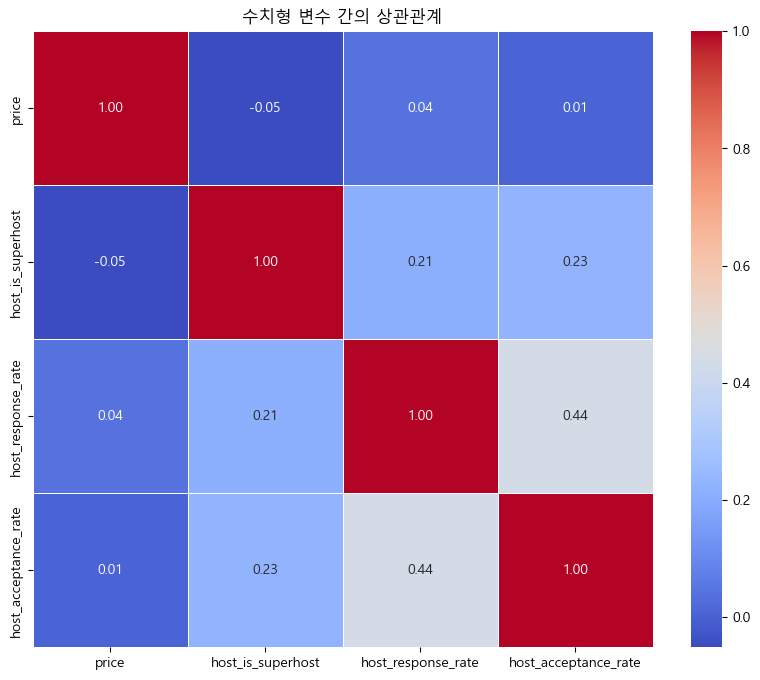

In [10]:
# 히트맵으로 확인
plt.figure(figsize=(10, 8))
sns.heatmap(df_host_relevant.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('수치형 변수 간의 상관관계')
plt.show()

In [11]:
# 호스트와 관련된 주요 변수와 가격과의 상관관계 분석 결과
print("호스트 관련 주요 변수와 가격과의 상관관계 분석 결과:")
print(df_host_relevant.corr()['price'].sort_values(ascending=False))

호스트 관련 주요 변수와 가격과의 상관관계 분석 결과:
price                   1.000000
host_response_rate      0.042325
host_acceptance_rate    0.006481
host_is_superhost      -0.051083
Name: price, dtype: float64


## price 변수들은 상관관계가 거의 없음. 
-> 슈퍼호스트라고 가격이 더 비싼 것도 아니였으며, 응답률과 수락률과는 상관관계가 미미한 수준이었다.

### **| 슈퍼호스트 유무(host_is_superhost)에 따른 추가 분석**

In [12]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 73 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            22308 non-null  int64  
 1   name                                          22308 non-null  str    
 2   description                                   21903 non-null  str    
 3   neighborhood_overview                         12262 non-null  str    
 4   host_id                                       22308 non-null  int64  
 5   host_name                                     22288 non-null  str    
 6   host_since                                    22288 non-null  str    
 7   host_location                                 17025 non-null  str    
 8   host_about                                    13391 non-null  str    
 9   host_response_time                            17915 non-null  str    
 1

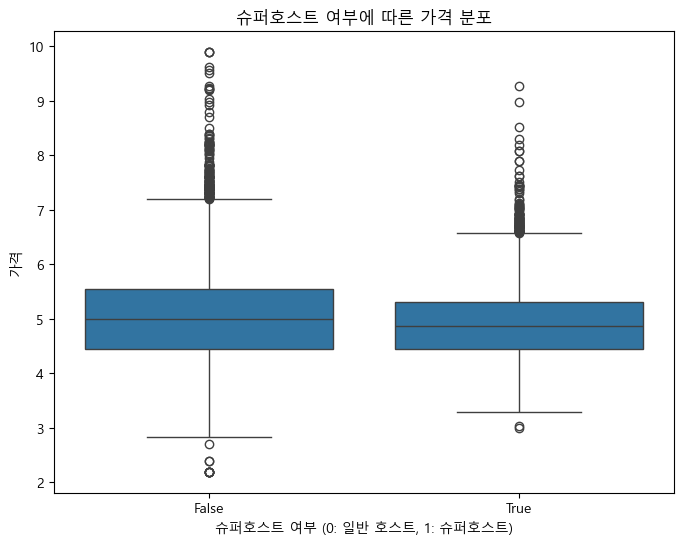

In [13]:
# 슈퍼호스트인 곳과 아닌 곳이 가격에 미치는 영향 분석
plt.figure(figsize=(8, 6))
sns.boxplot(x='host_is_superhost', y='log_price', data=df_cleaned)
plt.title('슈퍼호스트 여부에 따른 가격 분포')
plt.xlabel('슈퍼호스트 여부 (0: 일반 호스트, 1: 슈퍼호스트)')
plt.ylabel('가격')
plt.show()

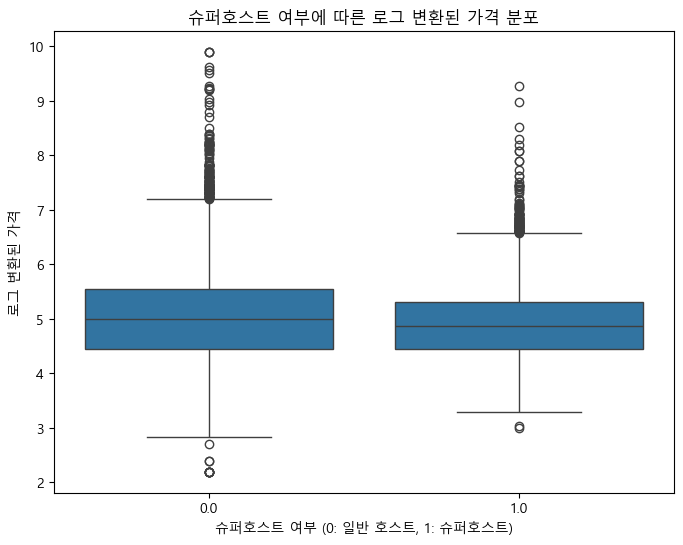

In [14]:
# 그래프가 보기 힘들어서 슈퍼 호스트인 곳과 아닌 곳의 가격 분포를 로그 변환하여 다시 시각화
plt.figure(figsize=(8, 6))
sns.boxplot(x='host_is_superhost', y=np.log1p(df_host_relevant['price']), data=df_host_relevant)
plt.title('슈퍼호스트 여부에 따른 로그 변환된 가격 분포')
plt.xlabel('슈퍼호스트 여부 (0: 일반 호스트, 1: 슈퍼호스트)')
plt.ylabel('로그 변환된 가격')
plt.show()

In [15]:
# 그룹별 요약 통계
comparison = df_host_relevant.groupby('host_is_superhost')['price'].agg(['mean', 'median', 'std', 'count']).round(2)
comparison.index = ['일반호스트(0)', '슈퍼호스트(1)']
display(comparison)

# 가격 차이 계산
mean_diff = comparison.loc['슈퍼호스트(1)', 'mean'] - comparison.loc['일반호스트(0)', 'mean']
print(f"\n평균 가격 차이: {mean_diff:.2f}달러")
# 중앙값 차이 계산
median_diff = comparison.loc['슈퍼호스트(1)', 'median'] - comparison.loc['일반호스트(0)', 'median']
print(f"중앙값 가격 차이: {median_diff:.2f}달러")

,mean,median,std,count
일반호스트(0),227.76,146.0,480.13,15799
슈퍼호스트(1),178.78,129.0,258.60,6135



평균 가격 차이: -48.98달러
중앙값 가격 차이: -17.00달러


In [16]:
from scipy import stats
# 슈퍼호스트인 집단과 아닌 집단의 가격 분리
superhost_price = df_host_relevant[df_host_relevant['host_is_superhost'] == 1]['price']
normalhost_price = df_host_relevant[df_host_relevant['host_is_superhost'] == 0]['price']

# T-검정 수행 (등분산 가정)
t_stat, p_val = stats.ttest_ind(superhost_price, normalhost_price, equal_var=True)

print(f"T-통계량: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("결론: 통계적으로 유의미한 가격 차이가 존재함.")
else:
    print("결론: 통계적으로 유의미한 차이가 없음.")

T-통계량: -7.5750
P-value: 0.0000
결론: 통계적으로 유의미한 가격 차이가 존재함.


In [17]:
# 진짜인지 효과 크기로 판단
effect_size = (comparison.loc['슈퍼호스트(1)', 'mean'] - comparison.loc['일반호스트(0)', 'mean']) / comparison.loc['일반호스트(0)', 'std']
print(f"효과 크기 (Cohen's d): {effect_size:.4f}")

# conhen's d 해석
if effect_size < 0.2:
    print("효과 크기 해석: 작은 효과")
elif effect_size < 0.5:
    print("효과 크기 해석: 중간 효과")
elif effect_size < 0.8:
    print("효과 크기 해석: 큰 효과")
else:
    print("효과 크기 해석: 매우 큰 효과")

효과 크기 (Cohen's d): -0.1020
효과 크기 해석: 작은 효과


### T-test에서는 유의미한 차이가 있을 것으로 보이지만, 실질상으로 효과크기 측면에서는 작은 효과로 보임. 
### 이에 유의미한 차이 없다고 판단됨

In [ ]:
# property_type : 57개 행
top_types = df_cleaned['property_type'].value_counts().nlargest(10).index
df_top = df_cleaned[df_cleaned['property_type'].isin(top_types)]

In [40]:
# property_type 행 수 및 컬럼
df_cleaned['property_type'].value_counts()
df_cleaned['property_type'].unique()

<StringArray>
[       'Private room in rental unit',              'Private room in condo',
               'Private room in home',                        'Entire home',
                 'Entire rental unit',        'Private room in guest suite',
                       'Entire place',                        'Entire loft',
                       'Entire condo',          'Private room in townhouse',
                   'Entire townhouse',  'Private room in bed and breakfast',
          'Entire serviced apartment',               'Private room in loft',
                  'Entire guesthouse',                 'Entire guest suite',
          'Private room in houseboat',             'Room in boutique hotel',
                       'Private room',         'Shared room in rental unit',
                               'Boat',         'Room in serviced apartment',
              'Private room in villa', 'Private room in religious building',
                    'Casa particular',                'Shared 

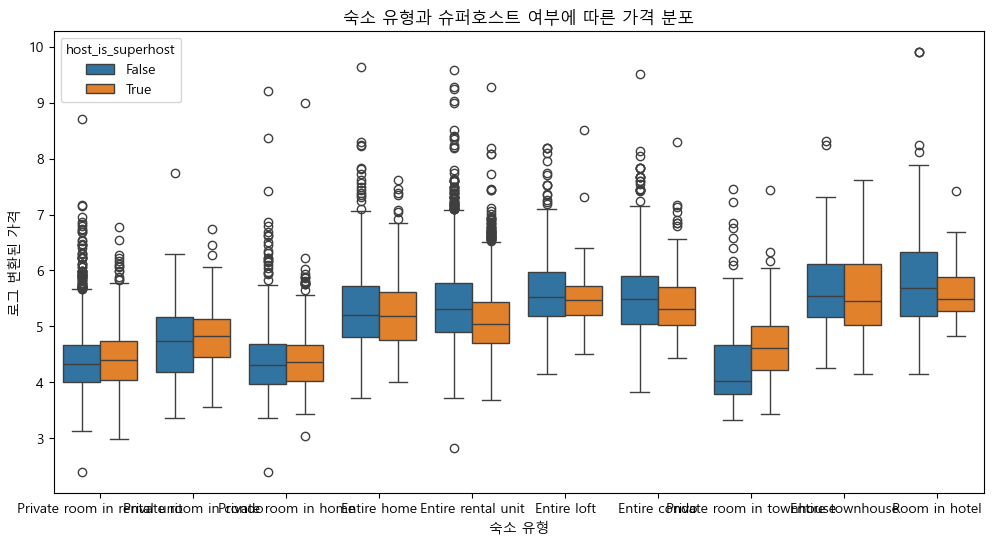

In [36]:
# property_type과 슈퍼호스트 유무가 가격과의 상관관계 분석
plt.figure(figsize=(12, 6))
sns.boxplot(x='property_type', y='log_price', hue='host_is_superhost', data=df_top)
plt.title('숙소 유형과 슈퍼호스트 여부에 따른 가격 분포')
plt.xlabel('숙소 유형')
plt.ylabel('로그 변환된 가격')
plt.show()

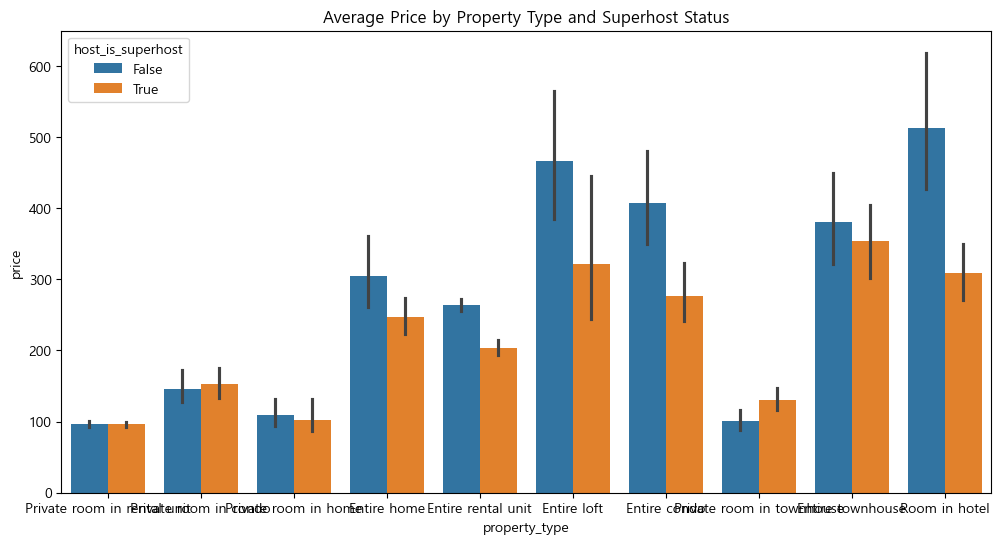

In [37]:
# property_type(숙소 타입)별로 슈퍼호스트의 가격 프리미엄이 있는지 확인
plt.figure(figsize=(12, 6))
sns.barplot(x='property_type', y='price', hue='host_is_superhost', data=df_top)
plt.title('Average Price by Property Type and Superhost Status')
plt.show()

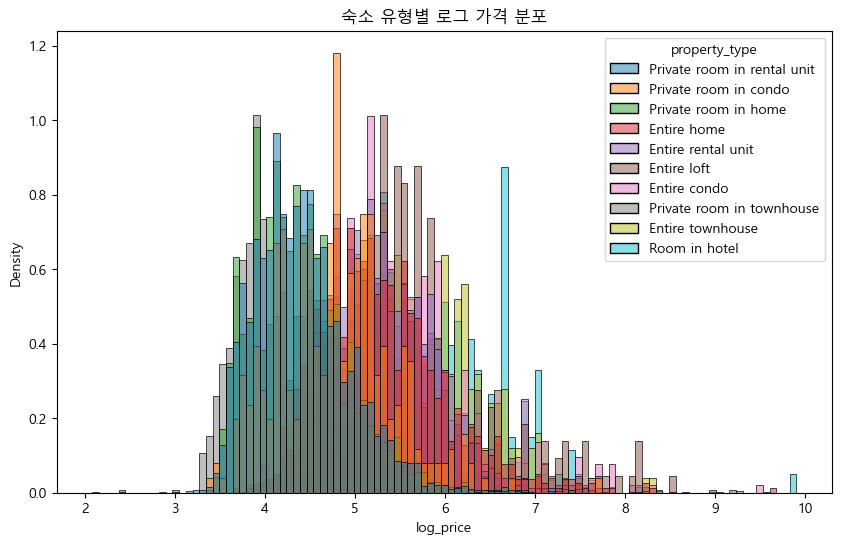

In [ ]:
# 특이한 숙소 유형과 슈퍼호스트 여부가 가격에 미치는 영향 분석
keywords = ['Boat', 'Cave', 'Treehouse', 'Castle', 'Camper', 'Tent', 'Barn', 'Tower', 'Casa'...]
mask = df_cleaned['property_type'].str.contains('|'.join(keywords), case=False, na=False)
df_unique = df_cleaned[mask]

In [23]:
# 룸 유형의 unique 값 확인
print(df_cleaned['room_type'].unique())
# 왜.. 아까 봤던 친구들 안 보이지...ㅜㅠ 바보 이슈..
 # Boat → 보트
 # Houseboat → 하우스보트
 # Casa particular → 카사 파르티쿨라르(쿠바식 민박)
 # Tiny home → 초소형 주택
 # Barn → 헛간 숙소
 # Camper/RV → 캠핑카
 # Tower → 타워형 숙소

<StringArray>
['Private room', 'Entire home/apt', 'Hotel room', 'Shared room']
Length: 4, dtype: str


### **| 호스트 응답률(host_response_rate)에 따른 추가 분석**

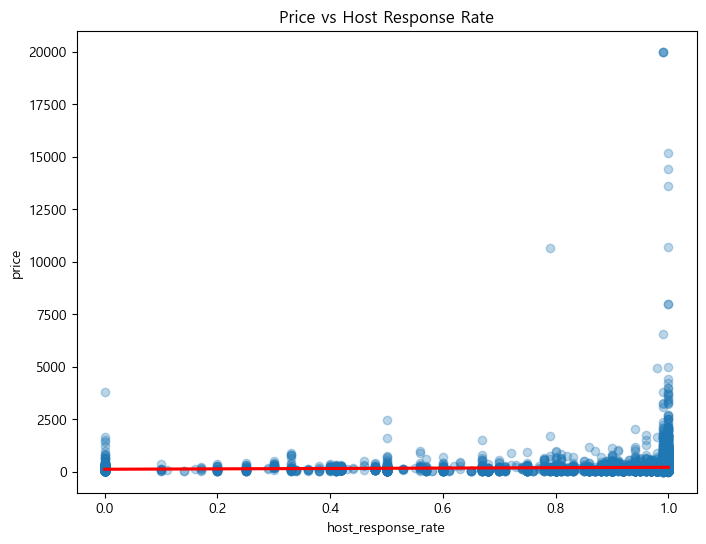

In [20]:
# 응답률과 가격의 관계
plt.figure(figsize=(8, 6))
sns.regplot(x='host_response_rate', y='price', data=df_host_relevant, 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Price vs Host Response Rate')
plt.show()

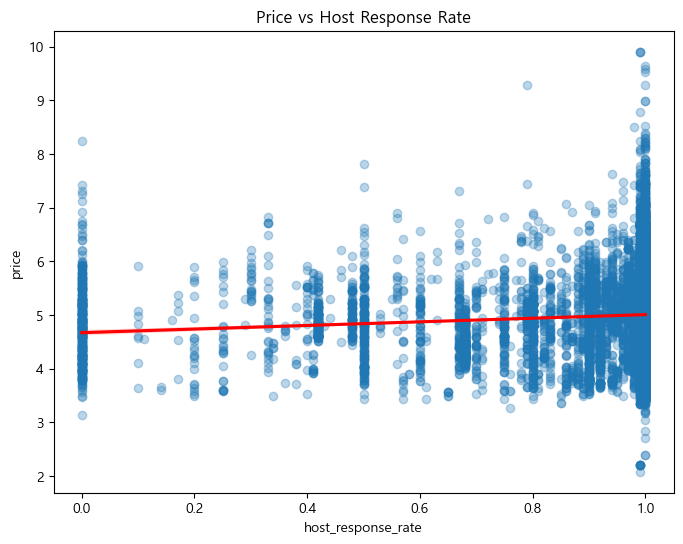

In [21]:
# 응답률과 가격의 관계(로그 변환)
plt.figure(figsize=(8, 6))
sns.regplot(x='host_response_rate', y=np.log1p(df_host_relevant['price']), data=df_host_relevant, 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Price vs Host Response Rate')
plt.show()

=> 응답률이 높아질수록 가격이 조금인 것같지만, 오르는 추세다.

& 오른다고 했던, 증거 추가 자료 필요..

### **| 호스트 수락률(host_acceptance_rate)에 따른 추가 분석**

### **숙소와 관련된 것들 확인**
property_type (숙소 타입), room_type (룸 타입)

비선형 구조인 것을 파악 -> 트리로 모델 정한다는 근거가 됨.
=> 해석이라는 걸로 붙어나가는데 쓰임.